# Credit Scoring Model

## Project Overview

This project develops a machine learning model to predict whether a credit applicant is likely to have Good or Bad credit risk.

The project uses the UCI German Credit dataset and compares multiple classification algorithms, including Logistic Regression, Decision Tree, and Random Forest.

The models are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Feature engineering, hyperparameter tuning, feature importance analysis, and decision-threshold optimization are also performed.

The final model is designed as an educational demonstration of a credit-risk classification workflow.

## Project Workflow

The project follows these main steps:

1. Load and inspect the German Credit dataset.
2. Explore the data and understand the distribution of credit risk.
3. Clean and prepare the features for machine learning.
4. Perform feature engineering by creating credit amount per month.
5. Encode categorical features and scale numerical features.
6. Split the data into training and testing sets.
7. Train and compare Logistic Regression, Decision Tree, and Random Forest models.
8. Evaluate the models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
9. Perform Random Forest hyperparameter tuning using cross-validation.
10. Analyze important features influencing the predictions.
11. Tune the Logistic Regression decision threshold to improve recall.
12. Save the final model and decision threshold.
13. Test the final model on a sample customer.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch the UCI German Credit dataset
credit_data = fetch_ucirepo(id=144)

# Separate features and target
X = credit_data.data.features
y = credit_data.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (1000, 20)
Target shape: (1000, 1)


In [ ]:
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [ ]:
y.head()

,class
0,1
1,2
2,1
3,1
4,2


In [ ]:
y.value_counts()

,count
class,
1,700
2,300


In [ ]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nColumn names:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isnull().sum())

Number of rows: 1000
Number of features: 20

Column names:
['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']

Missing values:
Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
Attribute17    0
Attribute18    0
Attribute19    0
Attribute20    0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Count the number of Good and Bad credit applicants
target_counts = y.value_counts()

print(target_counts)

class
1        700
2        300
Name: count, dtype: int64


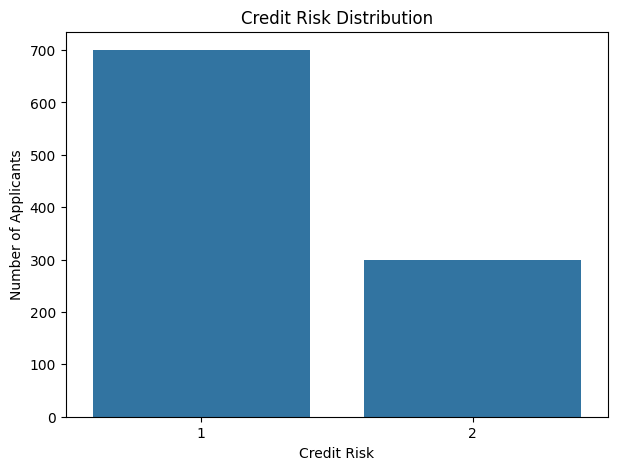

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y.iloc[:, 0])

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Applicants")

plt.show()

In [ ]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical features:", len(numeric_columns))
print("\nNumerical features:")
print(numeric_columns.tolist())

Number of numerical features: 7

Numerical features:
['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18']


In [ ]:
X[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Attribute2,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Attribute5,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Attribute8,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Attribute11,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Attribute13,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Attribute16,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
Attribute18,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


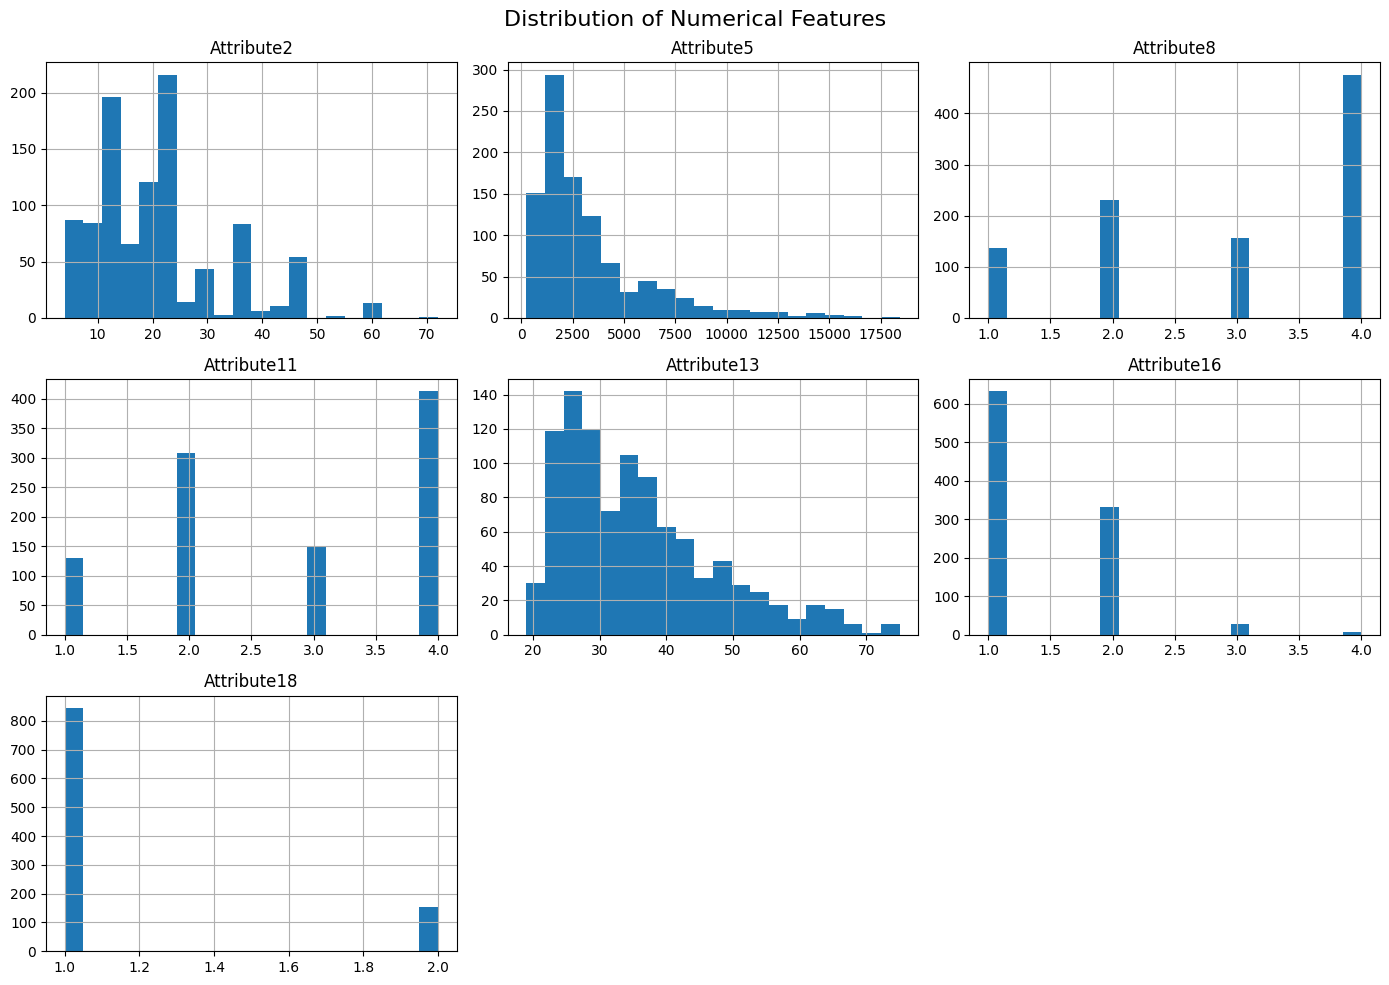

In [ ]:
X[numeric_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

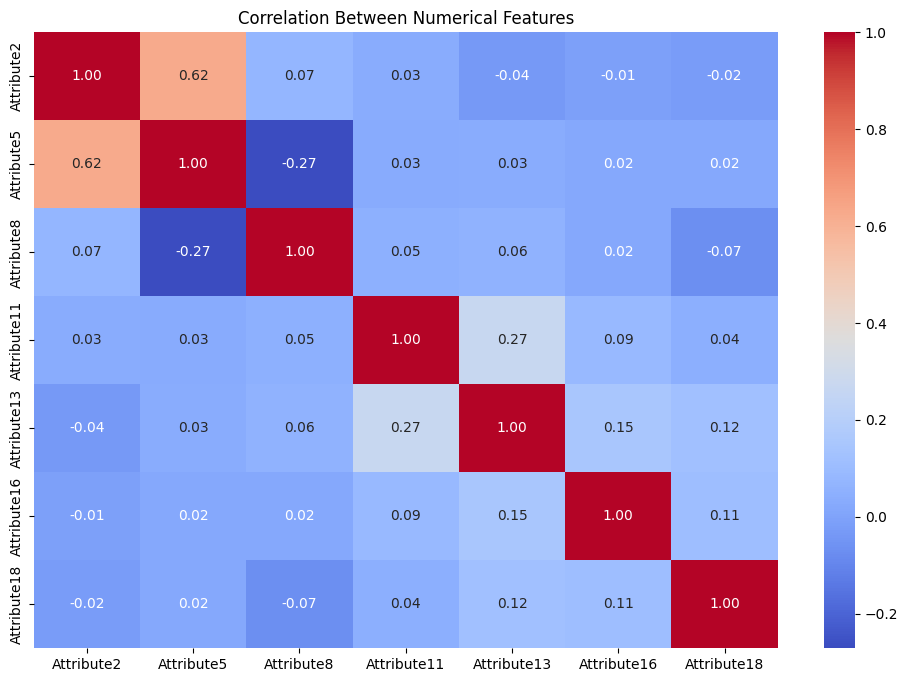

In [ ]:
correlation_matrix = X[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [ ]:
# Create a copy so that our original data remains unchanged
df = X.copy()

# Add the target column
df["Credit_Risk"] = y.iloc[:, 0]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 21)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
column_names = [
    "checking_account",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker"
]

df.columns = column_names + ["Credit_Risk"]

df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
df["Credit_Risk"] = df["Credit_Risk"].map({
    1: 0,
    2: 1
})

print(df["Credit_Risk"].value_counts())

Credit_Risk
0    700
1    300
Name: count, dtype: int64


In [ ]:
df["credit_per_month"] = (
    df["credit_amount"] / df["duration_months"]
)

df[[
    "credit_amount",
    "duration_months",
    "credit_per_month"
]].head()

,credit_amount,duration_months,credit_per_month
0,1169,6,194.833333
1,5951,48,123.979167
2,2096,12,174.666667
3,7882,42,187.666667
4,4870,24,202.916667


In [ ]:
X = df.drop("Credit_Risk", axis=1)
y = df["Credit_Risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 21)
y shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [ ]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Numerical features:
['duration_months', 'credit_amount', 'installment_rate', 'residence_duration', 'age', 'existing_credits', 'dependents', 'credit_per_month']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
categorical_features = [
    "checking_account",
    "credit_history",
    "purpose",
    "savings_account",
    "employment",
    "personal_status",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

numerical_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "dependents",
    "credit_per_month"
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Numerical features: ['duration_months', 'credit_amount', 'installment_rate', 'residence_duration', 'age', 'existing_credits', 'dependents', 'credit_per_month']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.785
Precision: 0.673469387755102
Recall   : 0.55
F1 Score : 0.6055045871559633
ROC-AUC  : 0.8057142857142857


Confusion Matrix:
[[124  16]
 [ 27  33]]


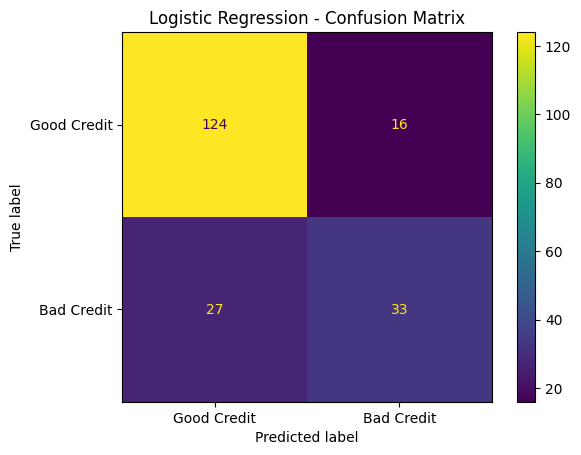

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good Credit", "Bad Credit"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
y_pred_dt = decision_tree_model.predict(X_test)
y_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_dt))

Decision Tree Results
---------------------
Accuracy : 0.725
Precision: 0.5714285714285714
Recall   : 0.3333333333333333
F1 Score : 0.42105263157894735
ROC-AUC  : 0.6858928571428572


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=8
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_rf))

Random Forest Results
---------------------
Accuracy : 0.785
Precision: 0.7575757575757576
Recall   : 0.4166666666666667
F1 Score : 0.5376344086021505
ROC-AUC  : 0.8013095238095238


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.785,0.673469,0.550000,0.605505,0.805714
1,Decision Tree,0.725,0.571429,0.333333,0.421053,0.685893
2,Random Forest,0.785,0.757576,0.416667,0.537634,0.801310


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 8, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best cross-validation ROC-AUC:
0.8008556547619048


In [ ]:
import matplotlib.pyplot as plt

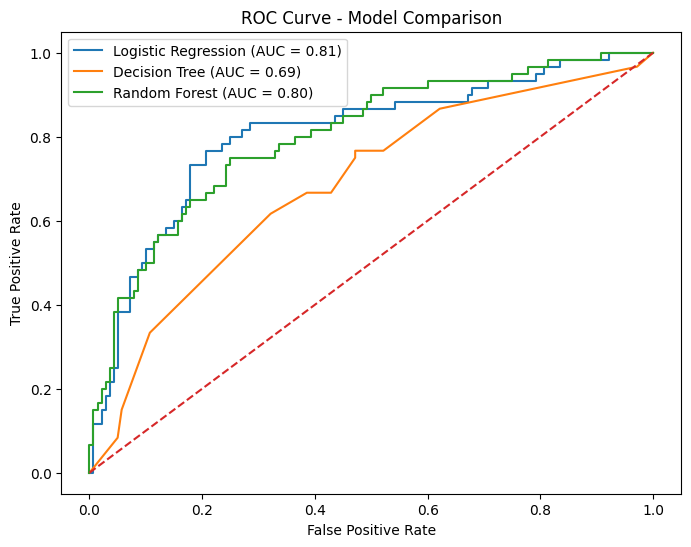

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.2f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.show()

In [ ]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load dataset
credit_data = fetch_ucirepo(id=144)

X = credit_data.data.features.copy()
y = credit_data.data.targets.copy()

# Rename columns
column_names = [
    "checking_account",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_duration",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker"
]

X.columns = column_names

# Create dataframe
df = X.copy()
df["Credit_Risk"] = y.iloc[:, 0]

# Convert target:
# 1 = Good Credit -> 0
# 2 = Bad Credit -> 1
df["Credit_Risk"] = df["Credit_Risk"].map({1: 0, 2: 1})

# Feature engineering
df["credit_per_month"] = (
    df["credit_amount"] / df["duration_months"]
)

# Separate features and target
X = df.drop("Credit_Risk", axis=1)
y = df["Credit_Risk"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature types
categorical_features = [
    "checking_account",
    "credit_history",
    "purpose",
    "savings_account",
    "employment",
    "personal_status",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

numerical_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "dependents",
    "credit_per_month"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Logistic Regression model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Recovery successful! ✅")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Model:", type(logistic_model).__name__)

Recovery successful! ✅
Training samples: 800
Testing samples: 200
Model: Pipeline


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    threshold_predictions = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, threshold_predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, threshold_predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, threshold_predictions, zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.563218,0.816667,0.666667
1,0.35,0.589744,0.766667,0.666667
2,0.40,0.632353,0.716667,0.671875
3,0.45,0.620690,0.600000,0.610169
4,0.50,0.673469,0.550000,0.605505
5,0.55,0.707317,0.483333,0.574257
6,0.60,0.714286,0.416667,0.526316


In [ ]:
# Improved decision threshold
best_threshold = 0.40

y_pred_threshold = (y_proba >= best_threshold).astype(int)

print("Final Threshold:", best_threshold)
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall:", recall_score(y_test, y_pred_threshold))
print("F1 Score:", f1_score(y_test, y_pred_threshold))

Final Threshold: 0.4
Precision: 0.6323529411764706
Recall: 0.7166666666666667
F1 Score: 0.671875


In [ ]:
def predict_credit_risk(input_data):
    probability = logistic_model.predict_proba(input_data)[0][1]

    if probability >= 0.40:
        result = "Bad Credit"
    else:
        result = "Good Credit"

    return result, probability


print("Improved prediction function created! ✅")
print("Decision threshold:", 0.40)

Improved prediction function created! ✅
Decision threshold: 0.4


In [ ]:
# Compare original and improved decision thresholds

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score"],
    "Threshold 0.50": [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Threshold 0.40": [
        precision_score(y_test, y_pred_threshold),
        recall_score(y_test, y_pred_threshold),
        f1_score(y_test, y_pred_threshold)
    ]
})

comparison

,Metric,Threshold 0.50,Threshold 0.40
0,Precision,0.673469,0.632353
1,Recall,0.550000,0.716667
2,F1 Score,0.605505,0.671875


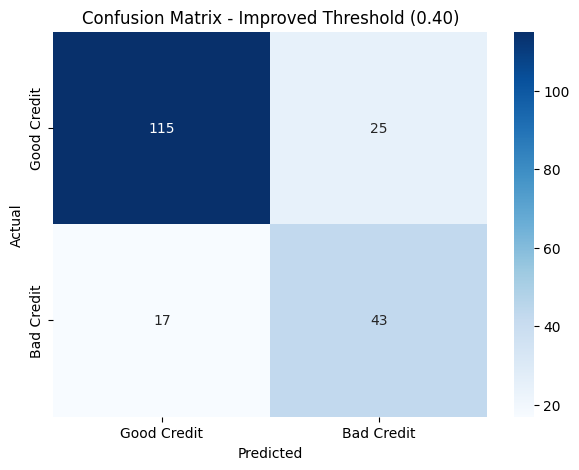

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_threshold = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved Threshold (0.40)")
plt.show()

In [ ]:
# Explain the prediction using Logistic Regression coefficients

feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Impact": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Impact",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Impact
24,cat__purpose_A46,0.898851,0.898851
11,cat__checking_account_A14,-0.887823,0.887823
16,cat__credit_history_A34,-0.802797,0.802797
18,cat__purpose_A41,-0.713347,0.713347
47,cat__property_A124,0.711042,0.711042
8,cat__checking_account_A11,0.657989,0.657989
27,cat__savings_account_A61,0.640200,0.640200
30,cat__savings_account_A64,-0.622195,0.622195
53,cat__housing_A153,-0.604374,0.604374
61,cat__foreign_worker_A202,-0.579254,0.579254


In [ ]:
# Group one-hot encoded features back into their original features

feature_importance["Original_Feature"] = feature_importance["Feature"].apply(
    lambda x: (
        x.replace("num__", "")
        if x.startswith("num__")
        else x.replace("cat__", "").rsplit("_", 1)[0]
    )
)

grouped_importance = (
    feature_importance
    .groupby("Original_Feature")["Absolute_Impact"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance.columns = ["Feature", "Maximum_Impact"]

grouped_importance.head(10)

,Feature,Maximum_Impact
0,purpose,0.898851
1,checking_account,0.887823
2,credit_history,0.802797
3,property,0.711042
4,savings_account,0.640200
5,housing,0.604374
6,foreign_worker,0.579254
7,employment,0.537113
8,personal_status,0.502012
9,other_debtors,0.453919


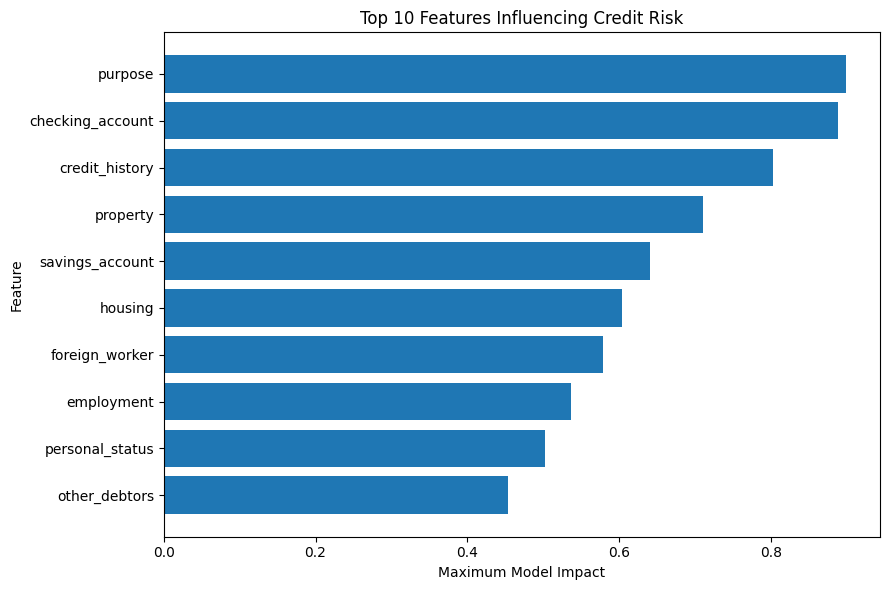

In [ ]:
# Top 10 Feature Influences

top_features = grouped_importance.head(10).sort_values(
    "Maximum_Impact",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Maximum_Impact"]
)

plt.xlabel("Maximum Model Impact")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Credit Risk")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Evaluation metrics imported successfully! ✅")

Evaluation metrics imported successfully! ✅


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Decision Tree
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]


# Random Forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=8
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]


# Make sure Logistic Regression predictions also exist
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Improved threshold
best_threshold = 0.40
y_pred_threshold = (y_proba >= best_threshold).astype(int)

print("All models and predictions restored successfully! ✅")
print("Logistic Regression:", len(y_pred))
print("Decision Tree:", len(y_pred_dt))
print("Random Forest:", len(y_pred_rf))
print("Improved threshold:", best_threshold)

All models and predictions restored successfully! ✅
Logistic Regression: 200
Decision Tree: 200
Random Forest: 200
Improved threshold: 0.4


In [ ]:
final_evaluation = pd.DataFrame({
    "Model": [
        "Logistic Regression (0.50)",
        "Decision Tree",
        "Random Forest",
        "Logistic Regression (0.40)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_threshold)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_threshold)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_threshold)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_threshold)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba)
    ]
})

final_evaluation

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (0.50),0.785,0.673469,0.550000,0.605505,0.805714
1,Decision Tree,0.725,0.571429,0.333333,0.421053,0.685893
2,Random Forest,0.785,0.757576,0.416667,0.537634,0.801310
3,Logistic Regression (0.40),0.790,0.632353,0.716667,0.671875,0.805714


## Final Model Selection

Logistic Regression was selected as the final model because it provided a strong balance between the evaluation metrics.

Initially, the model used the default decision threshold of 0.50. After testing multiple thresholds, a threshold of 0.40 was selected because it improved Recall from 55.0% to 71.7% and F1 Score from 0.606 to 0.672.

The final model achieved:
- Accuracy: 79.0%
- Precision: 63.2%
- Recall: 71.7%
- F1 Score: 67.2%
- ROC-AUC: 80.6%

The improved threshold helps the model identify more potentially bad-credit cases, although it also increases the number of Good Credit cases incorrectly classified as Bad Credit.

This project is intended for educational purposes and should not be used as a real-world credit approval system without further validation, fairness testing, larger datasets, and domain-specific requirements.

In [ ]:
%%writefile README.md

# Credit Scoring Model

## Project Overview

This project is a machine learning-based Credit Scoring Model developed as part of the CodeAlpha Machine Learning Internship.

The model predicts whether a customer is likely to have:

- Good Credit
- Bad Credit

The project demonstrates a complete machine learning workflow, including data exploration, preprocessing, feature engineering, model comparison, hyperparameter tuning, threshold optimization, evaluation, and prediction.

## Dataset

The project uses the UCI Statlog German Credit Data dataset.

- 1,000 records
- 20 original features
- Classification problem
- Numerical and categorical features

The target variable was converted into:

- 0 = Good Credit
- 1 = Bad Credit

## Machine Learning Models

Three classification algorithms were trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Categorical features were processed using One-Hot Encoding, while numerical features were standardized using StandardScaler.

The dataset was divided into:

- 80% training data
- 20% testing data

A stratified split was used to maintain the class distribution.

## Feature Engineering

A new feature called `credit_per_month` was created:

`credit_per_month = credit_amount / duration_months`

This represents the approximate credit amount per month.

## Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression (0.50) | 78.5% | 67.3% | 55.0% | 60.6% | 80.6% |
| Decision Tree | 72.5% | 57.1% | 33.3% | 42.1% | 68.6% |
| Random Forest | 78.5% | 75.8% | 41.7% | 53.8% | 80.1% |
| Logistic Regression (0.40) | **79.0%** | 63.2% | **71.7%** | **67.2%** | **80.6%** |

## Threshold Optimization

The original Logistic Regression model used the default probability threshold of 0.50.

Multiple thresholds were tested from 0.30 to 0.60.

A threshold of **0.40** was selected because it provided the best F1 Score among the tested thresholds while substantially improving Recall.

Recall improved from:

**55.0% → 71.7%**

F1 Score improved from:

**60.6% → 67.2%**

This means the improved model identifies more potentially bad-credit cases, although it also produces more false positives.

## Model Explainability

Logistic Regression coefficients were analyzed to understand which features had the strongest influence on the model.

The strongest feature influences included:

- Purpose
- Checking Account
- Credit History
- Property
- Savings Account
- Housing
- Foreign Worker
- Employment
- Personal Status
- Other Debtors

These represent model-derived associations and should not be interpreted as proof of causation.

## Example Prediction

A sample customer was tested using the trained model.

Prediction:

**Good Credit**

Original model probability of Bad Credit:

**19.86%**

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- UCI Machine Learning Repository

## Project Workflow

Data Collection
↓
Data Exploration
↓
Data Preprocessing
↓
Feature Engineering
↓
Train-Test Split
↓
Model Training
↓
Model Comparison
↓
Hyperparameter Tuning
↓
Threshold Optimization
↓
Model Explainability
↓
Final Evaluation
↓
Prediction

## Limitations

This project is intended for educational purposes.

The dataset is relatively small and historical, so the model should not be used directly for real-world lending or credit approval decisions without additional validation, fairness analysis, larger datasets, and domain-specific requirements.

Writing README.md


In [ ]:
import joblib

final_model_package = {
    "model": logistic_model,
    "threshold": 0.40
}

joblib.dump(final_model_package, "credit_scoring_final_model.pkl")

print("Final model package saved successfully! ✅")
print("Decision threshold:", final_model_package["threshold"])

Final model package saved successfully! ✅
Decision threshold: 0.4


In [ ]:
# Create a sample customer for testing

sample_customer = pd.DataFrame([{
    "checking_account": "A11",
    "duration_months": 12,
    "credit_history": "A32",
    "purpose": "A43",
    "credit_amount": 2500,
    "savings_account": "A61",
    "employment": "A73",
    "installment_rate": 2,
    "personal_status": "A93",
    "other_debtors": "A101",
    "residence_duration": 2,
    "property": "A121",
    "age": 25,
    "other_installment_plans": "A143",
    "housing": "A152",
    "existing_credits": 1,
    "job": "A173",
    "dependents": 1,
    "telephone": "A191",
    "foreign_worker": "A201",
    "credit_per_month": 2500 / 12
}])

# Load the final saved model
final_package = joblib.load("credit_scoring_final_model.pkl")

final_model = final_package["model"]
final_threshold = final_package["threshold"]

# Make prediction
sample_probability = final_model.predict_proba(sample_customer)[0][1]

if sample_probability >= final_threshold:
    final_prediction = "Bad Credit"
else:
    final_prediction = "Good Credit"

print("===== FINAL CREDIT RISK PREDICTION =====")
print()
print("Prediction:", final_prediction)
print(f"Probability of Bad Credit: {sample_probability:.2%}")
print(f"Decision Threshold: {final_threshold:.2f}")

===== FINAL CREDIT RISK PREDICTION =====

Prediction: Good Credit
Probability of Bad Credit: 19.86%
Decision Threshold: 0.40


## Limitations and Ethical Considerations

This project is developed for educational purposes using the UCI German Credit dataset.

The dataset contains only 1,000 records, so the model may not generalize to real-world credit applications.

The decision threshold was adjusted from 0.50 to 0.40 to improve recall for potentially bad-credit cases. This increases the number of cases identified as risky, but also increases false positives.

The threshold experiment was performed on the evaluation split, so a production-level system should select the threshold using a separate validation set and evaluate the final model once on an untouched test set.

Some input attributes may raise fairness and privacy concerns in real-world lending systems. Therefore, additional fairness testing, bias analysis, privacy safeguards, and domain-specific validation would be required before using such a model for actual credit decisions.

This model should not be used as an automated real-world credit approval system.

In [ ]:
# Verify the saved final model

import os
import joblib

model_file = "credit_scoring_final_model.pkl"

if os.path.exists(model_file):
    loaded_package = joblib.load(model_file)

    print("✅ Final model file found!")
    print("File:", model_file)
    print("Model:", type(loaded_package["model"]).__name__)
    print("Decision Threshold:", loaded_package["threshold"])
else:
    print("❌ Final model file not found.")

✅ Final model file found!
File: credit_scoring_final_model.pkl
Model: Pipeline
Decision Threshold: 0.4


In [ ]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
ucimlrepo
joblib

Writing requirements.txt


In [ ]:
%%writefile .gitignore

__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.streamlit/

Writing .gitignore
